In [ ]:
# 설계 문서 구성 요소

# 1. 프로젝트 개요
# input(듣기, 읽기), output(말하기,쓰기)를 통한 학습과 바로 이어지는 quiz 및 망각곡선을 활용한 복습 quiz로 언어학습을 효율적으로 할 수 있도록 돕는 에이전트 

# 2. 시스템 아키텍처
# state : 배운 내용 핵심 부분을 저장함 (초기 배운 날짜와 시간을 포함해서 저장, 복습 총 횟수 중 몇 번을 언제 했는지도 포함), 대화중에는 대화내용을 저장하는 state (종료하면 없어짐)

# node : 복습 날짜 계산 노드, 듣기 input 학습 노드, 읽기 input 학습 노드, 말하기 output 학습 노드, 쓰기 output 학습 노드, quiz 노드 

# 복습 날짜 계산 노드 :  오늘 (지금) 어떤 표현을 복습해야 하는지, 각 표현이 총 복습 수 중 몇 번째 복습을 하는건지. 결과적으로 어떤 표현을 복습해야 하는지 정리
# 복습 quiz 노드 : 복습 날짜 계산 노드에서 준 복습 해야 하는 내용들로 quiz 만들기. 총 문제 4개 중 2개는 ai 가 한국어로 그 표현 들어간 문장 물어보면 유저가 영어 말로 답해야함 (말하기 2개) + 2개는 그 표현이 들어간 질 좋은 아티클에서 문장 발췌해서 그 표현에만 구멍 뚫어서 아이엘츠 b1~c1 급으로 4지 선다 퀴즈 (문법+표현)
# 듣기 input 학습 노드 : 그 표현이 들어간 비디오 발췌.  https://youglish.com/, https://yarn.co/, https://www.playphrase.me/#/search?q=nice+to+meet+you&language=en 사이트 또는 유튜브에서 그 표현 들어간 유튜브 채널(애플뮤직 인터뷰, capital fm 인터뷰, chicken shop date, 유명한 브이로거)에서 그 표현이 들어간 부분을 뽑아서 영상 재생 바로 가능하게 해주고, 여러번 자동 재생. 
# 읽기 input 학습 노드 : 읽기는 x, thread, instagram, +양질의 뉴스 아티클(economics ...) 에서 그 표현이 들어간 부분을 뽑아서 바로 보여주는 기능이야. 간단히 언제 자주 사용되는 지 한국어 구어체로 가장 가까운 표현 알려줘. 
# 말하기 output 학습 노드 : 유저가 듣기 input 학습 노드로 학습하고 그 표현이 들어간 나만의 문장 만들어서 바로 비슷한 문장 말하면 그걸 맞게 썼는지 원어민이 알아들을 수 있는지 평가해줌. 
# 쓰기 output 학습 노드 : 유저가 읽기 input 학습 노드에서 학습하고 그 표현이 들어간 나만의 문장 만들어서 바로 비슷한 문장 쓰면 그걸 맞게 썼는지 원어민이 알아볼 수 있는지 평가해줌. 
# 학습 quiz 노드 :  말하기 output 학습 노드, 쓰기 output 학습 노드 내가 output 한 문장과 비슷한데 원어민이 자주 쓰는 문장으로 문제를 냄.  총 문제 4개 중 2개는 ai 가 한국어로 그 표현 들어간 문장 물어보면 유저가 영어 말로 답해야함 (말하기 2개) + 2개는 그 표현이 들어간 질 좋은 아티클에서 문장 발췌해서 그 표현에만 구멍 뚫어서 아이엘츠 b1~c1 급으로 4지 선다 퀴즈 (문법+표현)

# edge : 복습할 내용 있는지 확인 -> 있으면 복습먼저 없으면 -> 사용자가 내용 질문 혹은 배우고싶은 내용 적으면 -> 바로 input 듣기 학습 1개 -> 말하기 output 학습 1개 -> 읽기 input 학습 1개 -> 쓰기 output 1 개 -> 배운 내용으로 바로 각각에서 quiz 4문제 -> input듣기 ... quiz 까지 3번 반복 -> 복습 날짜 정하라고 물어봐 기본은 10분 뒤, 저녁 10시, 하루뒤, 일주일 뒤, 한달 뒤 

# 복습 날짜 계산 노드 -> 복습 quiz 노드 ->
# -> user input -> 듣기 input 학습 노드 -> 말하기 output 학습 노드  -> 읽기 input 학습 노드 > 쓰기 output 학습 노드 > 학습 quiz 노드 > 복습 날짜 계산 노드

# 3. 기술 스택
# 사용 라이브러리, API, 모델 명시
# 공통 기반
# Agent 프레임워크 : langgraph, langchain
# LLM :	OpenAI GPT-4o (문법평가, 퀴즈생성, 표현설명)
# STT (말하기 입력) : OpenAI Whisper API
# TTS (듣기 시뮬레이션) : OpenAI TTS API 
# 메모리/상태 저장 : SQLite + langgraph checkpointer
# 스케줄러 (복습 알람): APScheduler or Celery
# 알람 전송	: Telegram Bot API (추천)

# 복습 날짜 계산 노드 
# 망각곡선 계산 : Python 순수 로직 (Ebbinghaus)
# 날짜/시간 처리 : datetime, pytz
# 스케줄 저장 : SQLite
# 알람 발송: APScheduler + Telegram Bot API

# 듣기 input 학습 노드
# YouGlish 연동 : URL 파라미터 생성 + iframe embed
# Yarn.co 연동 : 비공식 API (yarn.co/api/search?query=)
# Playphrase 연동 : URL 파라미터 생성 (?q=expression)
# YouTube 채널 검색 : YouTube Data API v3
# 영상 재생 : IPython.display.HTML (Notebook) or 프론트엔드

# 읽기 input 학습 노드
# 뉴스 아티클 검색 : NewsAPI or Guardian API (무료)
# X(Twitter) : Twitter API v2 (유료 제한 있음)
# 대안 SNS 텍스트	: Reddit API (r/English, r/worldnews 등) — 무료
# 텍스트 파싱/하이라이트 : LLM + regex

# 말하기 output 학습 노드
# 음성 입력 : OpenAI Whisper API (STT)
# 발음/문법 평가 : GPT-4o 프롬프트 엔지니어링

# 쓰기 output 학습 노드
# 텍스트 입력 : 일반 input() or UI
# 문법/표현 평가 : GPT-4o

# quiz 노드
# 4지선다 문제 생성 : GPT-4o + Guardian/뉴스 아티클
# 말하기 퀴즈 답변 : Whisper API STT
# 채점 : GPT-4o


# 4. 데이터 흐름 / State 설계
# - LangGraph State 구조 정의


In [ ]:
import os
import re
import requests
from typing import TypedDict
from langgraph.graph import StateGraph, END
from langchain_openai import ChatOpenAI
from IPython.display import Image, display


os.environ["OPENAI_API_KEY"] = ""           # ← OpenAI 키
GUARDIAN_API_KEY=""   # ← Guardian 키

llm = ChatOpenAI(model="gpt-4o", temperature=0.7)
print("✅ 준비 완료!")

✅ 준비 완료!


In [ ]:
class State(TypedDict):
    phase             : str
    expression        : str

    article_title     : str
    article_date      : str
    article_url       : str
    article_body_en   : str   # 영어 원문 
    article_body_kr   : str   # 한국어 번역
    article_analysis  : str   # 표현 청크 분석
    article_examples  : str   # 예문 3개

    writing_input     : str
    writing_feedback  : str

    quiz_question     : str
    quiz_choices      : list
    quiz_answer       : str
    quiz_input        : str
    quiz_feedback     : str

print("✅ State 정의 완료!")

✅ State 정의 완료!


In [ ]:
# 1 세션 시작
def node_session_start(state: State) -> dict:
    print("\n" + "="*55)
    print("🚀  영어 학습 세션 시작!")
    print("="*55)
    return {"phase": "session_start"}


# 2 표현 입력
def node_expression_select(state: State) -> dict:
    print("\n[②] 오늘 배울 표현을 입력하세요")
    print("  예) break the ice / burn the midnight oil / hit the nail on the head")
    expression = input("  ✏️  표현 입력 → ").strip()
    print(f"  → 선택된 표현: '{expression}'")
    return {"phase": "expression_select", "expression": expression}


# 3 기사 읽기
def node_reading(state: State) -> dict:
    expr = state["expression"]
    print(f"\n[③] Guardian에서 '{expr}' 관련 기사 검색 중...")

    title, date, url, body_raw = "", "", "", ""

    try:
        # page-size=5 로 받아서 본문에 표현이 실제로 있는 기사 우선 선택
        resp = requests.get(
            "https://content.guardianapis.com/search",
            params={
                "q"           : expr,
                "api-key"     : GUARDIAN_API_KEY,
                "show-fields" : "bodyText",
                "page-size"   : 5,
                "lang"        : "en",
            },
            timeout=10
        )
        results = resp.json()["response"]["results"]

        chosen = None
        for r in results:
            body_candidate = r.get("fields", {}).get("bodyText", "")
            if expr.lower() in body_candidate.lower():
                chosen = r
                break
        if chosen is None and results:
            chosen = results[0]   # 없으면 첫 번째

        if chosen:
            title    = chosen["webTitle"]
            url      = chosen["webUrl"]
            date     = chosen.get("webPublicationDate", "")[:10]
            body_raw = chosen.get("fields", {}).get("bodyText", "")[:900]
            print(f"  → 기사 찾음: {title}")
        else:
            print("  → 검색 결과 없음")

    except Exception as e:
        print(f"  ⚠️  오류: {e}")

    # 영어 원문에서 표현 볼드 처리 
    # 대소문자 무관하게 표현 부분을 **표현** 으로 감쌈
    body_bold = re.sub(
        re.escape(expr),
        f"**{expr}**",
        body_raw,
        flags=re.IGNORECASE
    )

    # LLM: 번역 / 청크 분석 / 예문 3개 
    result = llm.invoke(f"""
        오늘 학습 표현: '{expr}'

        The Guardian 기사 정보:
        제목: {title}
        날짜: {date}
        본문: {body_raw}

        아래 형식을 정확히 지켜서 출력해줘. 각 섹션 제목은 그대로 유지해.

        [한국어 번역]
        기사 제목과 본문을 한국어로 자연스럽게 번역해줘. 실제 한국 기사 문체로.

        [🔍 실제 사용 분석]
        기사 본문에서 '{expr}' 표현이 등장하는 문장을 찾아줘.
        있으면: 해당 문장 영어 인용 → 앞뒤 청크(주어/전치사/목적어 등) 분석 → 한국어 번역
        없으면: '기사에 직접 등장하지 않지만,' 으로 시작하고 일반적인 문장 구조/청크 패턴 설명

        [📝 예문 3개]
        '{expr}' 을 사용한 자연스러운 영어 예문을 반드시 3개 만들어줘.
        예문마다 문장 구조(청크)가 서로 달라야 해. (with명사 / by-ing / 사물주어 등)
        표현 부분은 **별표**로 강조. 각 예문 바로 아래 한국어 번역.
        형식:
        1. (영어 예문)
        → (한국어 번역)
        2. (영어 예문)
        → (한국어 번역)
        3. (영어 예문)
        → (한국어 번역)
        """)
    llm_out = result.content.strip()

    # 섹션 파싱
    def extract_section(text, header):
        pattern = rf"\[{re.escape(header)}\](.*?)(?=\[|$)"
        m = re.search(pattern, text, re.DOTALL)
        return m.group(1).strip() if m else ""

    body_kr   = extract_section(llm_out, "한국어 번역")
    analysis  = extract_section(llm_out, "🔍 실제 사용 분석")
    examples  = extract_section(llm_out, "📝 예문 3개")

    # 출력 
    print(f"""
        {'='*55}
        📰  {title}
        📅  {date}  |  The Guardian
        🔗  {url}
        {'─'*55}
        [📄 영어 원문]
        {body_bold}
        {'─'*55}
        [🇰🇷 한국어 번역]
        {body_kr}
        {'─'*55}
        [🔍 실제 사용 분석]
        {analysis}
        {'─'*55}
        [📝 예문 3개]
        {examples}
        {'='*55}
        """)

    return {
        "phase"           : "reading",
        "article_title"   : title,
        "article_date"    : date,
        "article_url"     : url,
        "article_body_en" : body_bold,
        "article_body_kr" : body_kr,
        "article_analysis": analysis,
        "article_examples": examples,
    }


# 4 쓰기 연습
def node_writing(state: State) -> dict:
    expr = state['expression']

    print(f"""
{'='*55}
[✍️  쓰기 연습]
  📌 오늘의 표현: {expr}
  위 표현을 사용해서 영어 문장을 자유롭게 만들어보세요!
{'='*55}""")

    writing_input = input("\n  ✏️  문장 입력 → ").strip()

    print(f"""
{'─'*55}
📝 내가 쓴 문장:
   {writing_input}
{'─'*55}""")

    print("  💬 피드백 생성 중...")
    result = llm.invoke(f"""
학습 표현: '{expr}'
유저가 쓴 문장: '{writing_input}'

아래 4가지 항목으로 한국어 피드백을 줘. 각 항목 번호와 이모지 그대로 써줘.

1. ✅ 표현 사용 여부
- '{expr}' 을 문장에 실제로 사용했는지
- 표현 앞뒤 청크(전치사/목적어/주어 등)가 자연스러운지 구체적으로 설명

2. 🔧 문법 체크
- 시제, 관사, 전치사, 어순 오류가 있으면 틀린 부분 → 수정된 부분 형식으로 표시
- 오류 없으면 '문법 오류 없음' 명시

3. 💬 더 자연스러운 표현
- 원어민이 실제로 쓸 법한 버전으로 문장 전체를 다듬어줘
- 왜 더 자연스러운지 한 줄 이유 설명

4. ⭐ 총평
- 한 줄로 전체 평가 (예: '표현 사용은 정확하나 문법 보완 필요')
""")
    feedback = result.content.strip()

    print(f"""
💡 피드백:
{feedback}
{'─'*55}""")

    return {
        "phase"           : "writing",
        "writing_input"   : writing_input,
        "writing_feedback": feedback,
    }

# 5 퀴즈
def node_quiz(state: State) -> dict:
    print("\n" + "="*55)
    print("[❓ 4지선다 퀴즈]")
    print("  퀴즈 생성 중...")
    print("="*55)

    prompt = f"""
영어 표현 '{state['expression']}' 을 사용한 IELTS B2 수준의 자연스러운 영어 문장을 1개 만들어.
그 문장에서 '{state['expression']}' 부분만 _____로 바꿔서 빈칸 문제를 만들어줘.

보기 조건:
- 정답 1개: '{state['expression']}' 그대로
- 오답 3개: 비슷해 보이지만 의미/문법상 틀린 표현 (헷갈릴 만한 것)
- 보기 순서는 랜덤하게 섞어줘

반드시 아래 형식만 출력해. 다른 말 절대 붙이지 마:
Q. (빈칸 포함된 영어 문장)
A. (보기1)
B. (보기2)
C. (보기3)
D. (보기4)
정답: (A/B/C/D 중 하나만)
"""

    result = llm.invoke(prompt)

    # 파싱 
    lines = [l.strip() for l in result.content.strip().split("\n") if l.strip()]
    question, choices, answer = "", [], ""

    for line in lines:
        if line.startswith("Q."):
            question = line
        elif line.startswith(("A.", "B.", "C.", "D.")):
            choices.append(line)
        elif line.startswith("정답:"):
            answer = line.replace("정답:", "").strip()

    # 문제 화면 출력 
    print(f"\n{question}\n")
    for c in choices:
        print(f"   {c}")

    # 유저 입력 
    quiz_input = input("\n  ✏️  정답 입력 (A/B/C/D) → ").strip().upper()

    # 선택한 답 화면에 표시
    print("\n" + "─"*55)
    print(f"📝 내가 선택한 답: {quiz_input}")
    print("─"*55)

    if quiz_input == answer:
        feedback = f"✅ 정답!  선택: {quiz_input}  =  정답: {answer}"
    else:
        answer_text = next((c for c in choices if c.startswith(answer + ".")), answer)
        feedback = f"❌ 오답.  선택: {quiz_input}  |  정답: {answer_text}"

    print(f"\n{feedback}")

    return {
        "phase"        : "quiz",
        "quiz_question": question,
        "quiz_choices" : choices,
        "quiz_answer"  : answer,
        "quiz_input"   : quiz_input,
        "quiz_feedback": feedback,
    }



# 6 세션 완료
def node_save(state: State) -> dict:
    print(f"""
{'='*55}
🎉  세션 완료!
{'─'*55}
  📌 오늘 학습 표현  : '{state['expression']}'
  📰 읽은 기사       : {state['article_title']}
  ✍️  내가 쓴 문장    : {state['writing_input']}
  📝 퀴즈 결과       : {state['quiz_feedback']}
{'─'*55}
  수고했어요! 다음 복습일에 또 만나요 👋
{'='*55}
""")
    return {"phase": "done"}


print("✅ 노드 정의 완료!")

✅ 노드 정의 완료!


In [ ]:

StateGraph(State).add_node("node_session_start",     node_session_start)
StateGraph(State).add_node("node_expression_select", node_expression_select)
StateGraph(State).add_node("node_reading",           node_reading)
StateGraph(State).add_node("node_writing",           node_writing)
StateGraph(State).add_node("node_quiz",              node_quiz)
StateGraph(State).add_node("node_save",              node_save)

StateGraph(State).set_entry_point("node_session_start")

StateGraph(State).add_edge("node_session_start",     "node_expression_select")
StateGraph(State).add_edge("node_expression_select", "node_reading")
StateGraph(State).add_edge("node_reading",           "node_writing")
StateGraph(State).add_edge("node_writing",           "node_quiz")
StateGraph(State).add_edge("node_quiz",              "node_save")
StateGraph(State).add_edge("node_save",              END)

graph = g.compile()
print("✅ 그래프 조립 완료!")

✅ 그래프 조립 완료!


In [25]:
initial_state = State(
    phase="", expression="",
    article_title="", article_date="", article_url="",
    article_body_en="", article_body_kr="",
    article_analysis="", article_examples="",
    writing_input="", writing_feedback="",
    quiz_question="", quiz_choices=[], quiz_answer="",
    quiz_input="", quiz_feedback="",
)

final_state = graph.invoke(initial_state)


🚀  영어 학습 세션 시작!

[②] 오늘 배울 표현을 입력하세요
  예) break the ice / burn the midnight oil / hit the nail on the head
  → 선택된 표현: 'blatant'

[③] Guardian에서 'blatant' 관련 기사 검색 중...
  → 기사 찾음: CMA to investigate heating oil suppliers over ‘blatant profiteering’ from Iran war

📰  CMA to investigate heating oil suppliers over ‘blatant profiteering’ from Iran war
📅  2026-03-11  |  The Guardian
🔗  https://www.theguardian.com/business/2026/mar/11/heating-oil-profiteering-middle-east-us-israel-iran
───────────────────────────────────────────────────────
[📄 영어 원문]
Heating oil suppliers are to be investigated by the competition watchdog after accusations that firms are “**blatant**ly profiteering” from the conflict in the Middle East by doubling the prices they charge to households. The Competition and Markets Authority (CMA) said it had received “a number of concerning reports” in recent days from consumers reliant on heating oil about suppliers’ behaviour at a time of rising wholesale costs. About 1.7m 

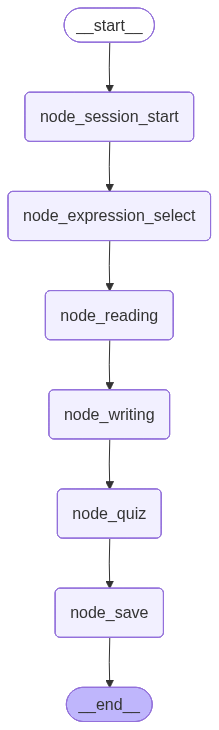

In [27]:

display(Image(graph.get_graph().draw_mermaid_png()))